# MC Agent Experiment

Notebook này train **Monte Carlo Agent** và so sánh với các baselines.

**Flow:**
1. Load baselines từ notebook 01 (hoặc chạy lại nhanh)
2. Train MC Agent 10 episodes (quick test)
3. Evaluate MC Agent
4. Visualize so sánh toàn diện

## 1. Setup

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import copy
from collections import deque

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from config import (
    BATCH_SIZE, CATEGORICAL_COLS,
    FULL_WINDOW_BATCHES, PARTIAL_WINDOW_BATCHES
)
from utils.data_loader import AirlinesDataLoader
from models.LightGBM import LightGBM
from metrics.stream_metrics import StreamMetrics
from environment.drift_env import DriftStreamEnv
from agents.mc_agent import MCAgent
from utils.visualizer import (
    plot_baseline_comparison,
    plot_dashboard,
    plot_cumulative_reward,
    plot_action_distribution,
    plot_agent_vs_baselines,
    plot_retrain_events,
)

print('Setup complete!')

Setup complete!


## 2. Load Data & Run Baselines

In [2]:
loader   = AirlinesDataLoader()
X_train, y_train = loader.get_initial_train_data()
print(f'Stream batches: {loader.n_batches}')

[DataLoader] Loading data from: c:\Users\LENOVO\Downloads\khu lap trinh\project1\project\data\Airlines.csv
[DataLoader] Raw shape: (539383, 9)
[DataLoader] 'Airline' → category dtype (18 unique values)
[DataLoader] 'AirportFrom' → category dtype (293 unique values)
[DataLoader] 'AirportTo' → category dtype (293 unique values)
[DataLoader] Initial train size : 20,000
[DataLoader] Stream size        : 519,383
[DataLoader] Features           : ['Airline', 'AirportFrom', 'AirportTo', 'Flight', 'DayOfWeek', 'Time', 'Length']
[DataLoader] Class distribution (train) – 0: 11,529 | 1: 8,471
Stream batches: 519


In [3]:
def run_baseline(strategy: str, retrain_every: int = 50) -> dict:
    """Chạy baseline strategy – copy từ notebook 01."""
    print(f'\n=== Running: {strategy.upper()} ===')
    clf     = LightGBM()
    metrics = StreamMetrics()
    clf.train(X_train, y_train)

    fold_size   = len(X_train) // 10
    init_errors = [
        clf.get_error_rate(
            X_train.iloc[i*fold_size:(i+1)*fold_size],
            y_train.iloc[i*fold_size:(i+1)*fold_size]
        ) for i in range(10)
    ]
    metrics.set_reference(init_errors)

    window_buffer  = deque(maxlen=FULL_WINDOW_BATCHES)
    retrain_events = []

    for X_batch, y_batch, idx in loader.stream_batches():
        window_buffer.append((X_batch, y_batch))

        if strategy == 'periodic' and idx > 0 and idx % retrain_every == 0:
            recent = list(window_buffer)
            X_w = pd.concat([b[0] for b in recent], ignore_index=True)
            y_w = pd.concat([b[1] for b in recent], ignore_index=True)
            for col in CATEGORICAL_COLS:
                X_w[col] = X_w[col].astype('category')
            clf.full_retrain(X_w, y_w)
            retrain_events.append(idx)

        preds      = clf.predict(X_batch)
        y_proba    = clf.predict_proba(X_batch)
        error_rate = clf.get_error_rate(X_batch, y_batch)
        metrics.update(y_batch.values, preds, error_rate, y_proba)

    print(f'  Done! Retrains: {len(retrain_events)}')
    return {
        'label'          : strategy,
        'prequential_acc': metrics.prequential_acc_history,
        'rolling_error'  : metrics.rolling_error_history,
        'drift_measure'  : metrics.drift_measure_history,
        'uncertainty'    : metrics.uncertainty_history,
        'retrain_events' : retrain_events,
        'final_summary'  : metrics.summary(),
    }

results_static   = run_baseline('static')
results_periodic = run_baseline('periodic', retrain_every=50)


=== Running: STATIC ===
[Classifier] Training on 20,000 samples...
[Classifier] Training complete.
[Metrics] Reference distribution set (10 samples).
  Done! Retrains: 0

=== Running: PERIODIC ===
[Classifier] Training on 20,000 samples...
[Classifier] Training complete.
[Metrics] Reference distribution set (10 samples).
[Classifier] Full retrain on 10,000 samples...
[Classifier] Full retrain complete. (update #1)
[Classifier] Full retrain on 10,000 samples...
[Classifier] Full retrain complete. (update #2)
[Classifier] Full retrain on 10,000 samples...
[Classifier] Full retrain complete. (update #3)
[Classifier] Full retrain on 10,000 samples...
[Classifier] Full retrain complete. (update #4)
[Classifier] Full retrain on 10,000 samples...
[Classifier] Full retrain complete. (update #5)
[Classifier] Full retrain on 10,000 samples...
[Classifier] Full retrain complete. (update #6)
[Classifier] Full retrain on 10,000 samples...
[Classifier] Full retrain complete. (update #7)
[Classifier

## 3. Train MC Agent (200 episodes)

In [4]:
# Khởi tạo environment và agent
clf     = LightGBM()
metrics = StreamMetrics()
env     = DriftStreamEnv(loader, clf, metrics)
agent   = MCAgent()

N_TRAIN_EPISODES = 200

# Train
training_history = agent.train(env, n_episodes=N_TRAIN_EPISODES, verbose=True)

print(f'\nStates visited: {len(agent.Q)}')
print(f'Preferences learned: {len(agent.H)}')


Training MCAgent for 200 episodes
[Classifier] Training on 20,000 samples...
[Classifier] Training complete.
[Metrics] Reference distribution set (10 samples).
[Classifier] Partial update on 1,000 samples (sliding window)...
[Classifier] Partial update complete. (update #1)
[Classifier] Full retrain on 4,000 samples...
[Classifier] Full retrain complete. (update #2)
[Classifier] Partial update on 2,000 samples (sliding window)...
[Classifier] Partial update complete. (update #3)
[Classifier] Partial update on 2,000 samples (sliding window)...
[Classifier] Partial update complete. (update #4)
[Classifier] Full retrain on 10,000 samples...
[Classifier] Full retrain complete. (update #5)
[Classifier] Full retrain on 10,000 samples...
[Classifier] Full retrain complete. (update #6)
[Classifier] Partial update on 2,000 samples (sliding window)...
[Classifier] Partial update complete. (update #7)
[Classifier] Partial update on 2,000 samples (sliding window)...
[Classifier] Partial update co

[Classifier] Full retrain complete. (update #9)
[Classifier] Partial update on 2,000 samples (sliding window)...
[Classifier] Partial update complete. (update #10)
[Classifier] Full retrain on 10,000 samples...
[Classifier] Full retrain complete. (update #11)
[Classifier] Partial update on 2,000 samples (sliding window)...
[Classifier] Partial update complete. (update #12)
[Classifier] Full retrain on 10,000 samples...
[Classifier] Full retrain complete. (update #13)
[Classifier] Full retrain on 10,000 samples...
[Classifier] Full retrain complete. (update #14)
[Classifier] Partial update on 2,000 samples (sliding window)...
[Classifier] Partial update complete. (update #15)
[Classifier] Partial update on 2,000 samples (sliding window)...
[Classifier] Partial update complete. (update #16)
[Classifier] Full retrain on 10,000 samples...
[Classifier] Full retrain complete. (update #17)
[Classifier] Partial update on 2,000 samples (sliding window)...
[Classifier] Partial update complete. (

In [5]:
agent.save(os.path.join(PROJECT_ROOT, 'experiments', 'results', 'mc_agent.pkl'))


[MCAgent] Saved → c:\Users\LENOVO\Downloads\khu lap trinh\project1\project\experiments\results\mc_agent.pkl


## 4. Evaluate MC Agent

In [6]:
def evaluate_agent(agent: MCAgent, env: DriftStreamEnv, n_episodes: int = 3) -> dict:
    """
    Evaluate agent trên N episodes, lấy trung bình metrics.
    Trong evaluation, vẫn dùng learned policy nhưng ghi lại metrics đầy đủ.
    """
    print(f'\n=== Evaluating {agent.name} ({n_episodes} episodes) ===')

    all_preq_acc    = []
    all_rolling_err = []
    all_drift       = []
    all_uncertainty = []
    all_rewards     = []
    all_actions     = []
    retrain_events  = []

    for ep in range(n_episodes):
        state    = env.reset(start_batch=0)
        ep_reward = 0.0
        step     = 0

        while not env.is_done:
            action, pi = agent.select_action(state)
            next_state, reward, done, info = env.step(
                action, pi=pi, update_explorer=False
            )
            ep_reward += reward
            if done and "action_taken" not in info:
                state = next_state
                break
            all_actions.append(info['action_taken'])

            if info['action_taken'] in ['partial_update', 'full_retrain']:
                retrain_events.append(step)

            step  += 1
            state  = next_state

        all_rewards.append(ep_reward)
        all_preq_acc.append(env.metrics.prequential_acc_history)
        all_rolling_err.append(env.metrics.rolling_error_history)
        all_drift.append(env.metrics.drift_measure_history)
        all_uncertainty.append(env.metrics.uncertainty_history)
        print(f'  Episode {ep+1}: reward={ep_reward:.2f}')

    # Lấy trung bình theo từng batch
    min_len = min(len(h) for h in all_preq_acc)

    avg_preq_acc    = np.mean([h[:min_len] for h in all_preq_acc],    axis=0).tolist()
    avg_rolling_err = np.mean([h[:min_len] for h in all_rolling_err], axis=0).tolist()
    avg_drift       = np.mean([h[:min_len] for h in all_drift],       axis=0).tolist()
    avg_uncertainty = np.mean([h[:min_len] for h in all_uncertainty], axis=0).tolist()

    # Action distribution
    action_dist = {}
    for a in all_actions:
        action_dist[a] = action_dist.get(a, 0) + 1

    print(f'\n  Avg reward     : {np.mean(all_rewards):.4f} ± {np.std(all_rewards):.4f}')
    print(f'  Final preq acc : {avg_preq_acc[-1]:.4f}')
    print(f'  Final roll err : {avg_rolling_err[-1]:.4f}')
    print(f'  Action dist    : {action_dist}')

    return {
        'label'          : agent.name,
        'prequential_acc': avg_preq_acc,
        'rolling_error'  : avg_rolling_err,
        'drift_measure'  : avg_drift,
        'uncertainty'    : avg_uncertainty,
        'episode_rewards': all_rewards,
        'action_dist'    : action_dist,
        'retrain_events' : retrain_events,
    }

results_mc = evaluate_agent(agent, env, n_episodes=3)


=== Evaluating MCAgent (3 episodes) ===
[Classifier] Training on 20,000 samples...
[Classifier] Training complete.
[Metrics] Reference distribution set (10 samples).
[Classifier] Partial update on 1,000 samples (sliding window)...
[Classifier] Partial update complete. (update #1)
[Classifier] Partial update on 2,000 samples (sliding window)...
[Classifier] Partial update complete. (update #2)
[Classifier] Partial update on 2,000 samples (sliding window)...
[Classifier] Partial update complete. (update #3)
[Classifier] Partial update on 2,000 samples (sliding window)...
[Classifier] Partial update complete. (update #4)
[Classifier] Partial update on 2,000 samples (sliding window)...
[Classifier] Partial update complete. (update #5)
[Classifier] Partial update on 2,000 samples (sliding window)...
[Classifier] Partial update complete. (update #6)
[Classifier] Partial update on 2,000 samples (sliding window)...
[Classifier] Partial update complete. (update #7)
[Classifier] Partial update 

## 5. Summary Table

In [7]:
print('\n' + '='*65)
print(f"{'Strategy':<20} {'Preq Acc':>10} {'Roll Err':>10} {'Retrains':>10}")
print('='*65)

for name, results in [
    ('Static',      results_static),
    ('Periodic',    results_periodic),
    ('MC Agent',    results_mc),
]:
    preq = results['prequential_acc'][-1]
    err  = results['rolling_error'][-1]
    n_rt = len(results['retrain_events'])
    print(f"{name:<20} {preq:>10.4f} {err:>10.4f} {n_rt:>10}")

print('='*65)


Strategy               Preq Acc   Roll Err   Retrains
Static                   0.6259     0.4360          0
Periodic                 0.6377     0.3980         10
MC Agent                 0.8983     0.0900       1546


## 6. Visualize: Learning Curve

[Visualizer] Saved → c:\Users\LENOVO\Downloads\khu lap trinh\project1\project\experiments\results\mc_cumulative_reward.png


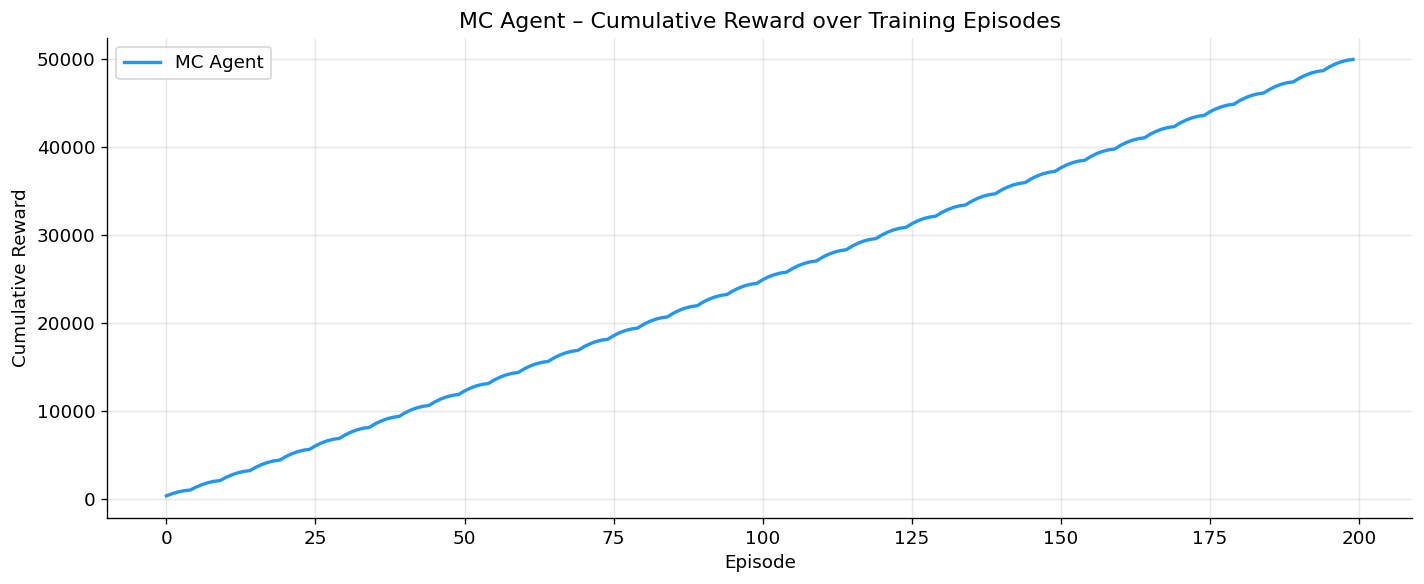

In [8]:
# Reward qua các episodes training
plot_cumulative_reward(
    {'MC Agent': training_history['episode_rewards']},
    title    = 'MC Agent – Cumulative Reward over Training Episodes',
    filename = 'mc_cumulative_reward.png',
)

## 7. Visualize: MC Agent Dashboard

[Visualizer] Saved → c:\Users\LENOVO\Downloads\khu lap trinh\project1\project\experiments\results\mc_dashboard.png


c:\Users\LENOVO\Downloads\khu lap trinh\project1\project\utils\visualizer.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


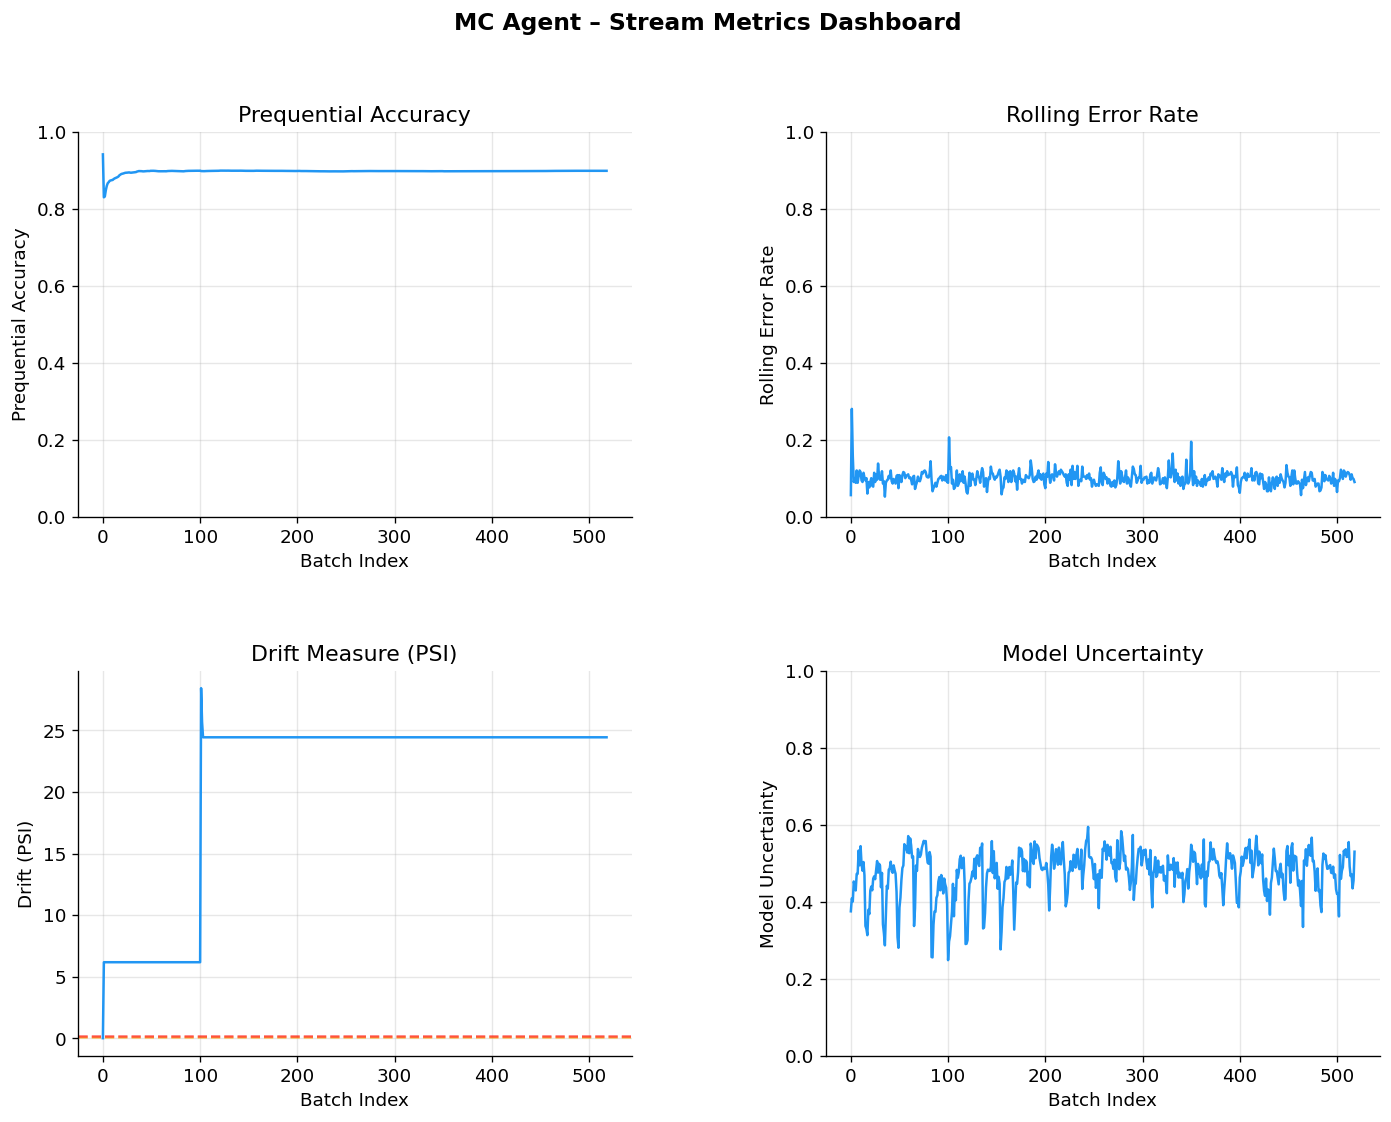

In [9]:
plot_dashboard(
    results_mc,
    title    = 'MC Agent – Stream Metrics Dashboard',
    filename = 'mc_dashboard.png',
)

## 8. Visualize: MC Agent vs Baselines

[Visualizer] Saved → c:\Users\LENOVO\Downloads\khu lap trinh\project1\project\experiments\results\mc_vs_baselines_acc.png


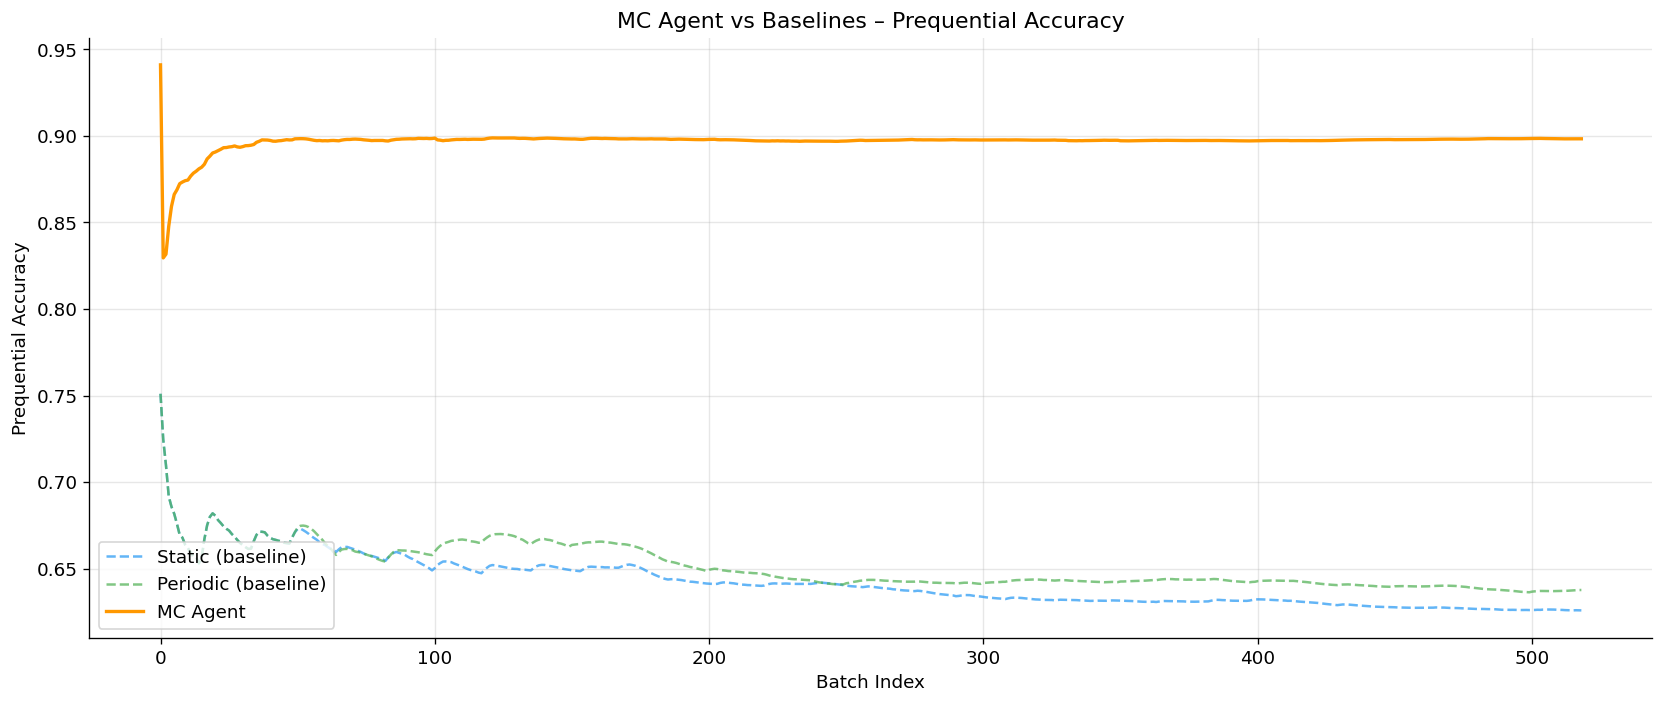

[Visualizer] Saved → c:\Users\LENOVO\Downloads\khu lap trinh\project1\project\experiments\results\mc_vs_baselines_err.png


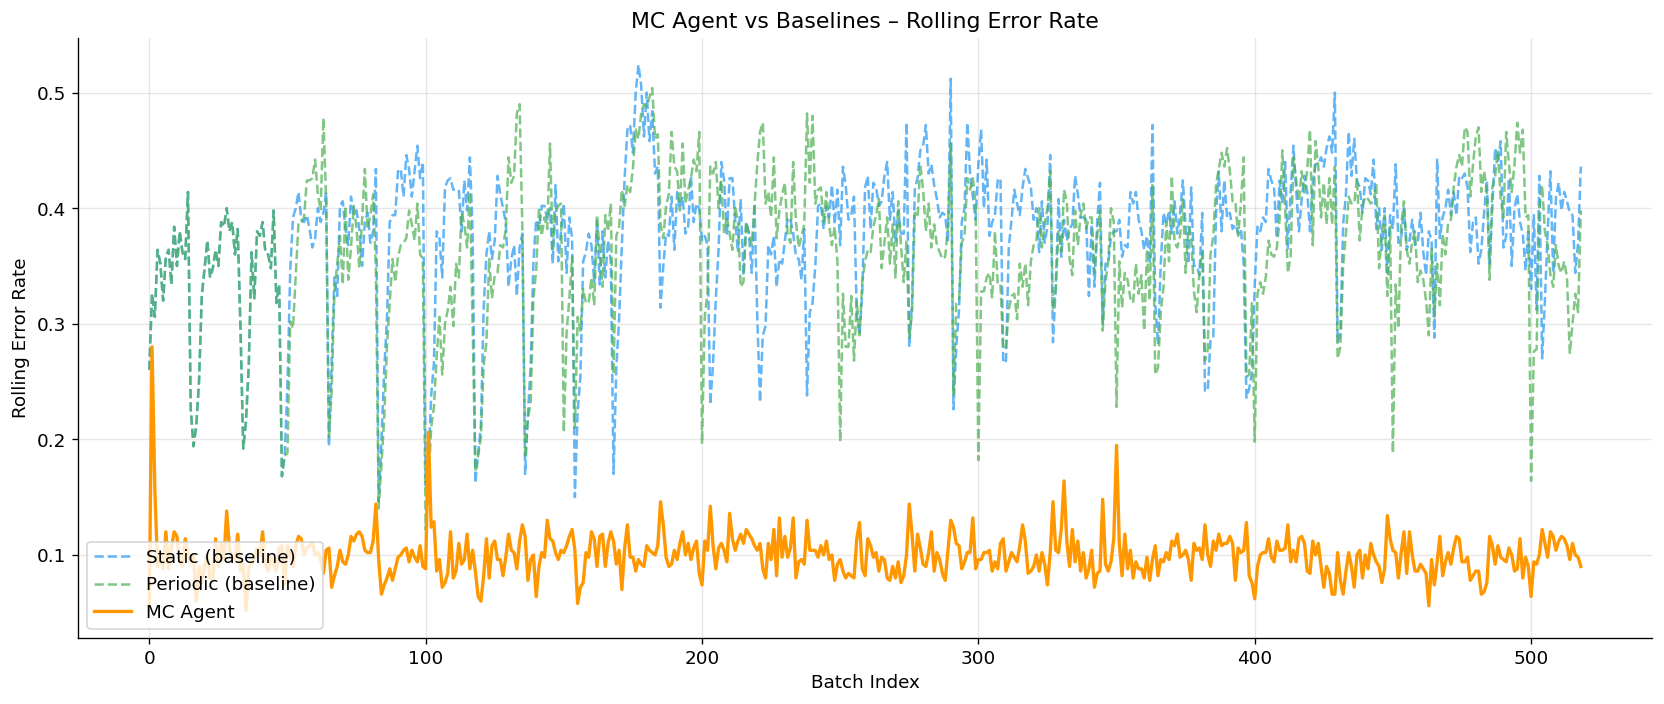

In [10]:
plot_agent_vs_baselines(
    baselines = {
        'Static'  : results_static['prequential_acc'],
        'Periodic': results_periodic['prequential_acc'],
    },
    agents  = {'MC Agent': results_mc['prequential_acc']},
    ylabel  = 'Prequential Accuracy',
    title   = 'MC Agent vs Baselines – Prequential Accuracy',
    filename= 'mc_vs_baselines_acc.png',
)

plot_agent_vs_baselines(
    baselines = {
        'Static'  : results_static['rolling_error'],
        'Periodic': results_periodic['rolling_error'],
    },
    agents  = {'MC Agent': results_mc['rolling_error']},
    ylabel  = 'Rolling Error Rate',
    title   = 'MC Agent vs Baselines – Rolling Error Rate',
    filename= 'mc_vs_baselines_err.png',
)

## 9. Visualize: Action Distribution

[Visualizer] Saved → c:\Users\LENOVO\Downloads\khu lap trinh\project1\project\experiments\results\mc_action_dist.png


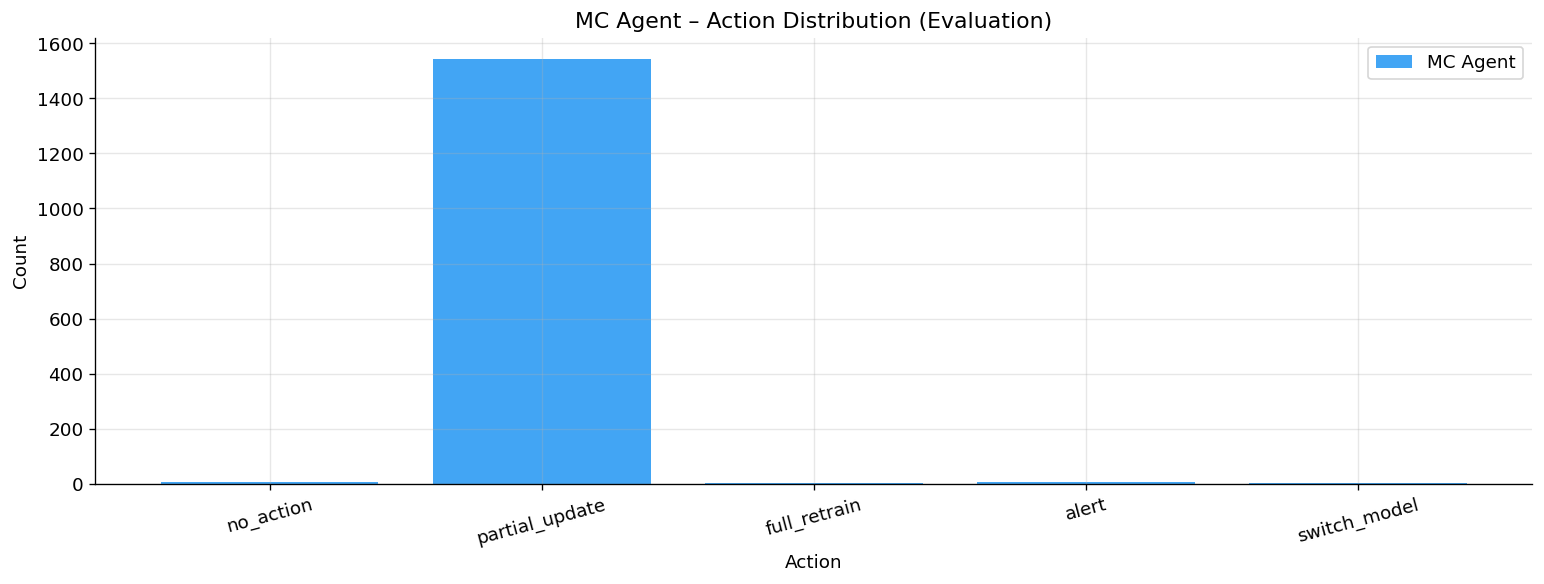

In [11]:
plot_action_distribution(
    {'MC Agent': results_mc['action_dist']},
    title    = 'MC Agent – Action Distribution (Evaluation)',
    filename = 'mc_action_dist.png',
)

## 10. Visualize: Retrain Events

[Visualizer] Saved → c:\Users\LENOVO\Downloads\khu lap trinh\project1\project\experiments\results\mc_retrain_events.png


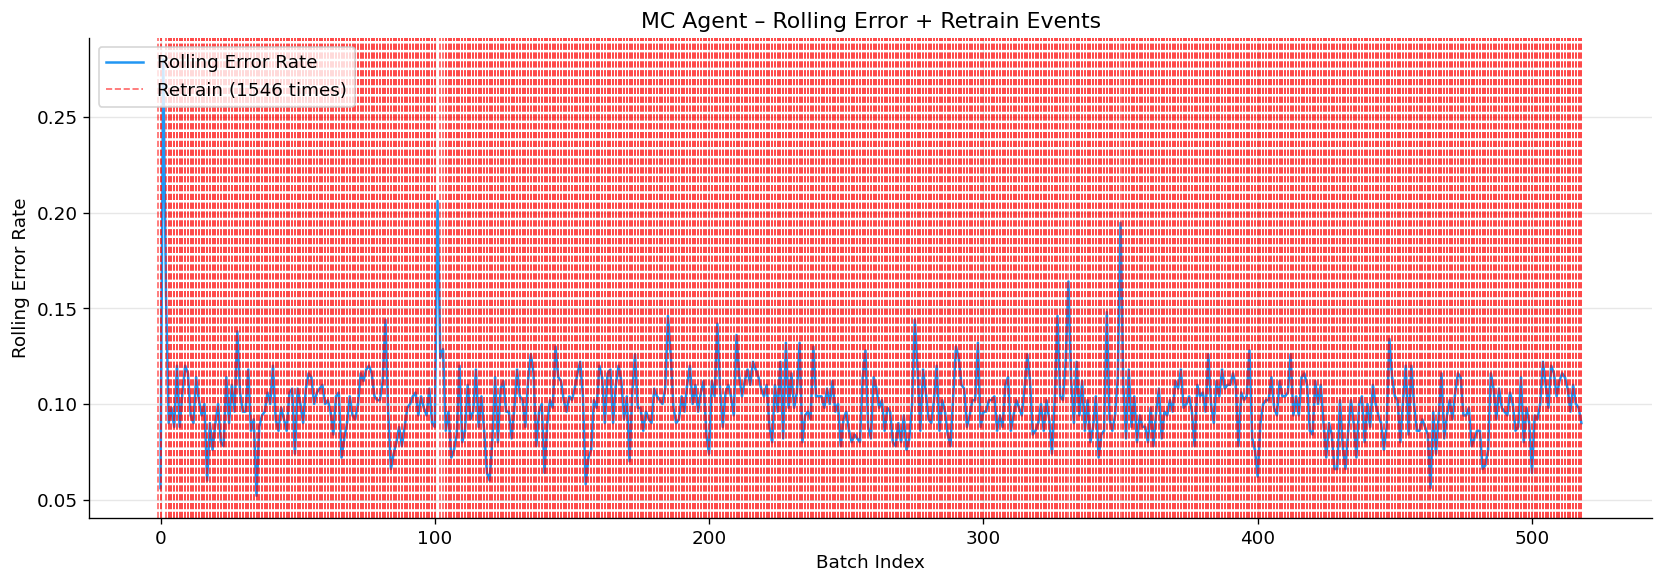

In [12]:
plot_retrain_events(
    results_mc['rolling_error'],
    results_mc['retrain_events'],
    title    = 'MC Agent – Rolling Error + Retrain Events',
    filename = 'mc_retrain_events.png',
)

## 11. Observations

Ghi lại nhận xét sau khi chạy:

**Learning curve:**
- Reward có tăng dần qua các episodes không?
- Bao nhiêu episodes để bắt đầu hội tụ?

**So sánh với baselines:**
- MC Agent có prequential accuracy cao hơn Static không?
- MC Agent có rolling error thấp hơn Periodic không?
- Số lần retrain của MC Agent so với Periodic (50 batches cố định)?

**Action distribution:**
- Agent có học được khi nào nên retrain không?
- Hay vẫn đang distribute đều giữa các actions?

→ Nếu kết quả tốt: tăng lên 50 episodes để thấy convergence rõ hơn.
→ Nếu kết quả chưa tốt: kiểm tra reward function, learning rate, gamma.